In [90]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("stephanmatzka/predictive-maintenance-dataset-ai4i-2020")

print("Path to dataset files:", path)

Path to dataset files: /home/dave/.cache/kagglehub/datasets/stephanmatzka/predictive-maintenance-dataset-ai4i-2020/versions/2


In [91]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv(path + '/ai4i2020.csv')

print(df.head())


target = df['Machine failure']
df = df.drop(columns=['UDI','Product ID', 'Type', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'Machine failure'])

df.columns = df.columns.str.replace('[', '').str.replace(']', '')

print(df.head())
print(df.info())
print(target.value_counts())

   UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860    M                298.1                    308.6   
1    2     L47181    L                298.2                    308.7   
2    3     L47182    L                298.1                    308.5   
3    4     L47183    L                298.2                    308.6   
4    5     L47184    L                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Machine failure  TWF  \
0                    1551         42.8                0                0    0   
1                    1408         46.3                3                0    0   
2                    1498         49.4                5                0    0   
3                    1433         39.5                7                0    0   
4                    1408         40.0                9                0    0   

   HDF  PWF  OSF  RNF  
0    0    0    0    0  
1    0    0    0    0  
2    0  

In [92]:
df['Temperature Difference'] = df['Process temperature K'] - df['Air temperature K']
df['Power'] = df['Rotational speed rpm'] * df['Torque Nm']
df['Energy'] = df['Power'] * df['Tool wear min']

In [93]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(df, target, test_size=0.2, random_state=42)

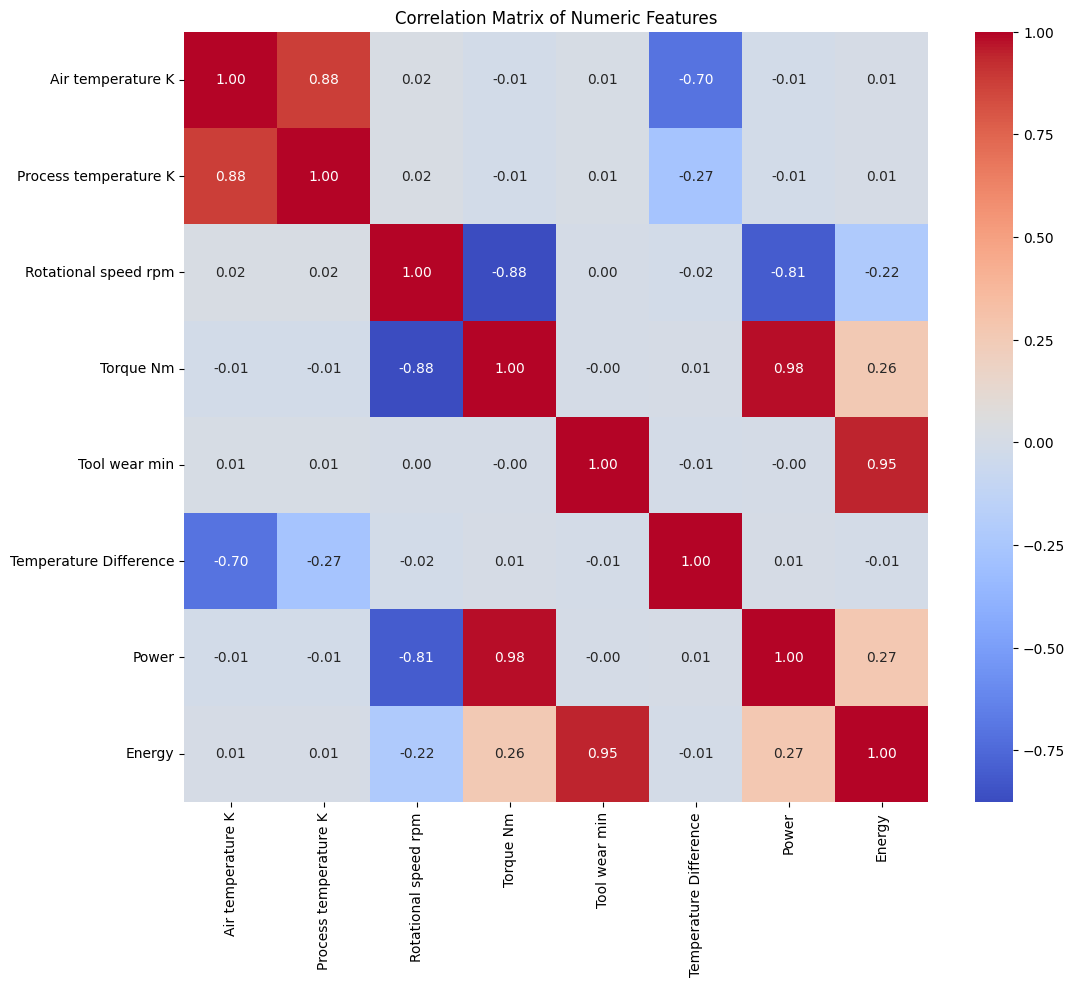

In [94]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns for correlation matrix
numeric_df = df.select_dtypes(include=['number'])

correlation_matrix = numeric_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numeric Features')
plt.show()

In [95]:
import os 

n_jobs = round(os.cpu_count() / 2)

In [96]:
import optuna
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score

# IMPORTANTE! Ratio per il modello
ratio = (y_train == 0).sum() / (y_train == 1).sum()

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True), 
        'max_depth': trial.suggest_int('max_depth', 3, 7), 
        'n_estimators': trial.suggest_int('n_estimators', 100, 500), 
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 5, 20), 
        'gamma': trial.suggest_float('gamma', 1.0, 5.0), 
        'reg_alpha': trial.suggest_float('reg_alpha', 0.1, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.1, 10.0, log=True)  
    }

    model = XGBClassifier(**params, scale_pos_weight = ratio, random_state=42, n_jobs=n_jobs)
    return cross_val_score(model, x_train, y_train, cv=5, scoring='f1').mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"Best CV Precision:  {study.best_value:.4f}")
print(f"Best params: {study.best_params}")

Best trial: 43. Best value: 0.777746: 100%|██████████| 50/50 [00:45<00:00,  1.11it/s]

Best CV Precision:  0.7777
Best params: {'learning_rate': 0.09939203187514604, 'max_depth': 6, 'n_estimators': 280, 'subsample': 0.7359387887685128, 'colsample_bytree': 0.8272085136512245, 'min_child_weight': 5, 'gamma': 1.0074679783008413, 'reg_alpha': 0.9937647209032511, 'reg_lambda': 1.8540271652329752}


In [97]:
from sklearn.metrics import classification_report

best_model = XGBClassifier(**study.best_params, scale_pos_weight=ratio, random_state=42, n_jobs=n_jobs)
best_model.fit(x_train, y_train)

print("TRAIN:")
print(classification_report(y_train, best_model.predict(x_train)))
print("TEST:")
print(classification_report(y_test, best_model.predict(x_test)))

TRAIN:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00      7722
           1       0.85      1.00      0.92       278

    accuracy                           0.99      8000
   macro avg       0.92      1.00      0.96      8000
weighted avg       0.99      0.99      0.99      8000

TEST:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1939
           1       0.71      0.82      0.76        61

    accuracy                           0.98      2000
   macro avg       0.85      0.90      0.88      2000
weighted avg       0.99      0.98      0.99      2000



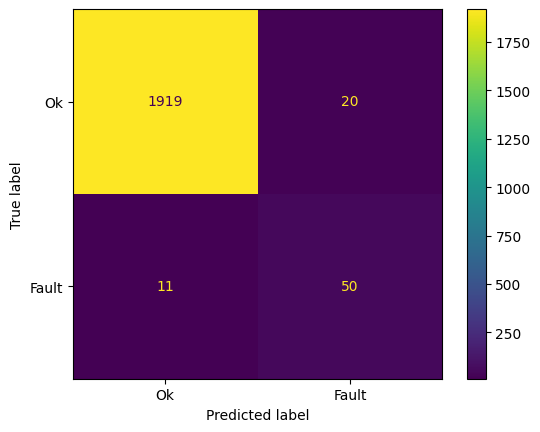

In [98]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(best_model, x_test, y_test, display_labels=['Ok', 'Fault'])
plt.show()
plt.close()